# Ejercicio 4 - Segmentación de Imágenes Médicas

En esta seccion, desarrollaremos el EDA y ETL de la base de datos de **"Segmentación de Imágenes Médicas"** con el fin de comprender y analizar la problematica planteada.

A continuacion, instalaremos las librerias quer seran utilizadas a lo largo del ejercicio.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tifffile as tiff
import json
from matplotlib.patches import Polygon
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from joblib import dump, load
from PIL import Image
import json
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split, KFold

In [2]:
df2 = pd.read_csv("HuBMAP-20-dataset_information.csv")
df2 = pd.DataFrame(df2)

df2

,image_file,width_pixels,height_pixels,anatomical_structures_segmention_file,glomerulus_segmentation_file,patient_number,race,ethnicity,sex,age,weight_kilograms,height_centimeters,bmi_kg/m^2,laterality,percent_cortex,percent_medulla
0,aa05346ff.tiff,47340,30720,aa05346ff-anatomical-structure.json,aa05346ff.json,67347,White,Not Hispanic or Latino,Female,58,59.0,160.0,23.0,Right,80,20
1,afa5e8098.tiff,43780,36800,afa5e8098-anatomical-structure.json,afa5e8098.json,67347,White,Not Hispanic or Latino,Female,58,59.0,160.0,23.0,Right,55,45
2,54f2eec69.tiff,22240,30440,54f2eec69-anatomical-structure.json,54f2eec69.json,67548,Black or African American,Not Hispanic or Latino,Male,58,79.9,190.5,22.0,Right,75,25
3,d488c759a.tiff,29020,46660,d488c759a-anatomical-structure.json,d488c759a.json,68138,White,Not Hispanic or Latino,Female,66,81.5,158.8,32.2,Left,100,0
4,1e2425f28.tiff,32220,26780,1e2425f28-anatomical-structure.json,1e2425f28.json,63921,White,Not Hispanic or Latino,Male,48,131.5,193.0,35.3,Right,65,35
5,e79de561c.tiff,27020,16180,e79de561c-anatomical-structure.json,e79de561c.json,67026,Black or African American,Not Hispanic or Latino,Male,53,73.0,166.0,26.5,Left,55,45
6,c68fe75ea.tiff,49780,26840,c68fe75ea-anatomical-structure.json,c68fe75ea.json,67112,White,Not Hispanic or Latino,Male,56,91.2,167.6,32.5,Left,80,20
7,095bf7a1f.tiff,39000,38160,095bf7a1f-anatomical-structure.json,095bf7a1f.json,68250,White,Not Hispanic or Latino,Female,44,71.7,160.0,28.0,Right,65,35
8,26dc41664.tiff,42360,38160,26dc41664-anatomical-structure.json,26dc41664.json,68304,White,Not Hispanic or Latino,Female,66,71.3,167.6,25.4,Left,55,45
9,57512b7f1.tiff,43160,33240,57512b7f1-anatomical-structure.json,57512b7f1.json,68555,White,Not Hispanic or Latino,Female,76,93.0,157.4,37.5,Left,80,20


In [3]:
print("\n Estructura del dataset:")
print(df2.shape)

print("\n Nombre de variables")
print(df2.columns)


 Estructura del dataset:
(20, 16)

 Nombre de variables
Index(['image_file', 'width_pixels', 'height_pixels',
       'anatomical_structures_segmention_file', 'glomerulus_segmentation_file',
       'patient_number', 'race', 'ethnicity', 'sex', 'age', 'weight_kilograms',
       'height_centimeters', 'bmi_kg/m^2', 'laterality', 'percent_cortex',
       'percent_medulla'],
      dtype='object')


In [4]:
df2.isnull().sum()

image_file                               0
width_pixels                             0
height_pixels                            0
anatomical_structures_segmention_file    0
glomerulus_segmentation_file             0
patient_number                           0
race                                     0
ethnicity                                0
sex                                      0
age                                      0
weight_kilograms                         1
height_centimeters                       1
bmi_kg/m^2                               1
laterality                               0
percent_cortex                           0
percent_medulla                          0
dtype: int64

Observamos que la base de datos contiene datos faltanes. Estos se encuentran en la muestra dek paciente '65631' el cual presenta NA en las variables 'height_centimeters', 'weight_kilograms', 'bmi_kg/m^2'. Al tener una base de datos con pocas muestras (20 en total), decidimos reemplazar los valores de NA por la mediana de cada variable en funcion del sexo, de esta forma mantenemos la armonia estadistica de los datos.

In [5]:
df2['height_centimeters'] = df2.groupby('sex')['height_centimeters'].transform(
    lambda x: x.fillna(x.median())
)

df2['weight_kilograms'] = df2.groupby('sex')['weight_kilograms'].transform(
    lambda x: x.fillna(x.median())
)

df2['bmi_kg/m^2'] = df2.groupby('sex')['bmi_kg/m^2'].transform(
    lambda x: x.fillna(x.median())
)

df2.isnull().sum()

image_file                               0
width_pixels                             0
height_pixels                            0
anatomical_structures_segmention_file    0
glomerulus_segmentation_file             0
patient_number                           0
race                                     0
ethnicity                                0
sex                                      0
age                                      0
weight_kilograms                         0
height_centimeters                       0
bmi_kg/m^2                               0
laterality                               0
percent_cortex                           0
percent_medulla                          0
dtype: int64

Observamos que una vez realizado este cambio, contamos con la base de datos completa y con esto procederemos con el analisis demografico.

#### Analisis demografico

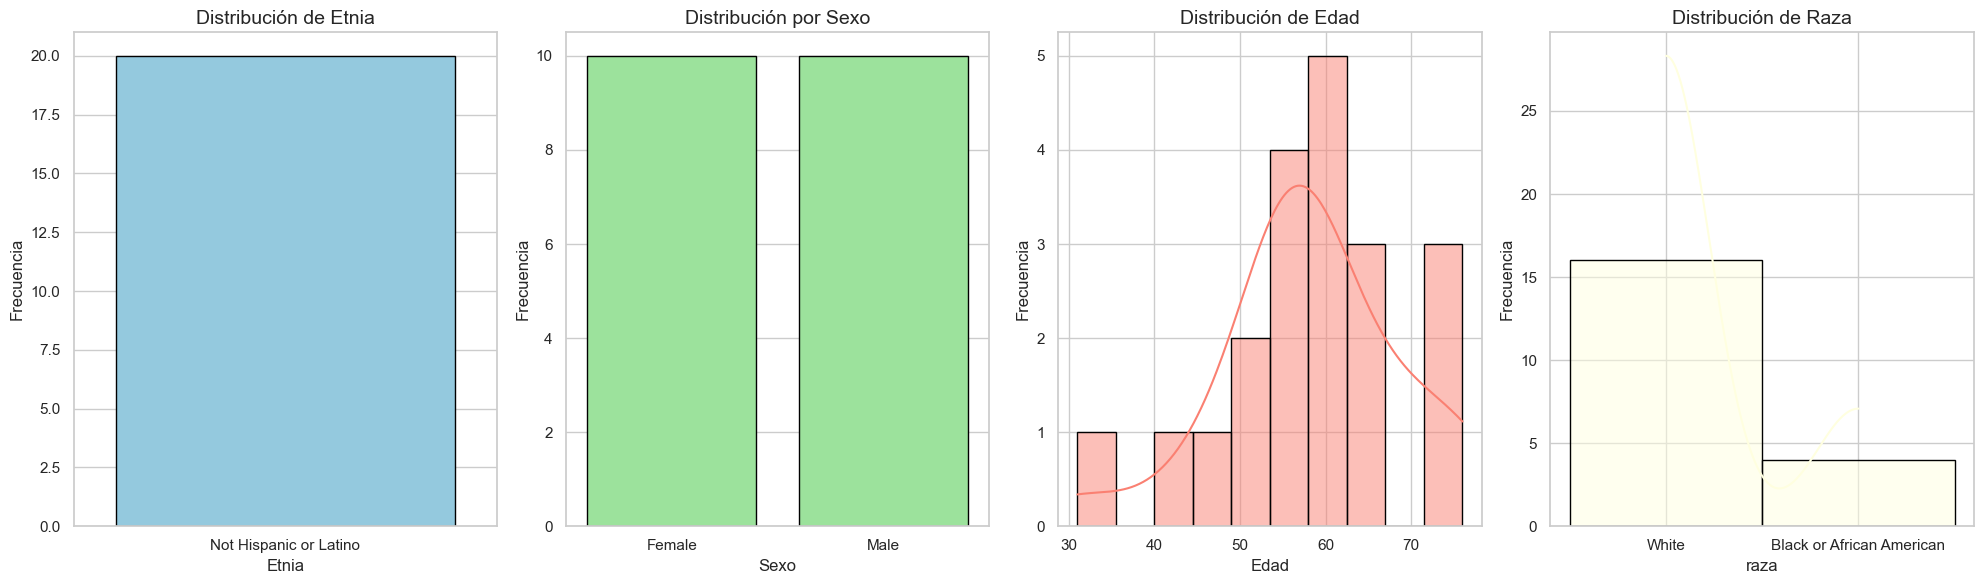

In [6]:
# Estilo general
sns.set(style="whitegrid", palette="pastel")
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

#  Gráfico de Etnia (categórica)
sns.countplot(data=df2, x='ethnicity', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Distribución de Etnia', fontsize=14)
axes[0].set_xlabel('Etnia')
axes[0].set_ylabel('Frecuencia')

# 2. Gráfico de Sexo (categórica)
sns.countplot(data=df2, x='sex', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Distribución por Sexo', fontsize=14)
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Frecuencia')

# 3. Histograma de Edad (numérica)
sns.histplot(data=df2, x='age', bins=10, kde=True, ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Distribución de Edad', fontsize=14)
axes[2].set_xlabel('Edad')
axes[2].set_ylabel('Frecuencia')

# 3. Histograma de Edad (numérica)
sns.histplot(data=df2, x='race', bins=10, kde=True, ax=axes[3], color='lightyellow', edgecolor='black')
axes[3].set_title('Distribución de Raza', fontsize=14)
axes[3].set_xlabel('raza')
axes[3].set_ylabel('Frecuencia')

# Mostrar todo junto
plt.tight_layout()
plt.show()

Distribución de Etnia
En cuanto a la distribución de etnia, se observa que la totalidad de los registros corresponde a la categoría "Not Hispanic or Latino". Todos los individuos comparten esta misma clasificación, por lo que la gráfica muestra una única barra con una frecuencia de 20 observaciones. Esta característica no presenta variabilidad dentro del conjunto de datos.

Distribución por Sexo
La variable sexo se encuentra equilibrada en la muestra. Se registran 10 personas del sexo femenino y 10 del sexo masculino, lo que representa una distribución completamente simétrica. Esta igualdad en la cantidad de casos permite realizar análisis sin sesgos relacionados con el género.

Distribución de Edad
La distribución de edades indica que la mayoría de las personas se encuentran en el rango de 50 a 65 años, siendo esta la franja con mayor concentración de individuos. Las edades oscilan aproximadamente entre los 30 y los 75 años. Además, la curva de densidad sugiere una ligera asimetría, con una mayor acumulación en edades intermedias y una disminución progresiva hacia edades más avanzadas.

Distribución de Raza
Respecto a la raza, la mayoría de los individuos están clasificados como "White", con una frecuencia aproximada de 16 personas. Por otro lado, la categoría "Black or African American" cuenta con una menor frecuencia, cercana a las 4 observaciones.

/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/1418853411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='sex', y='age', palette='Set3')


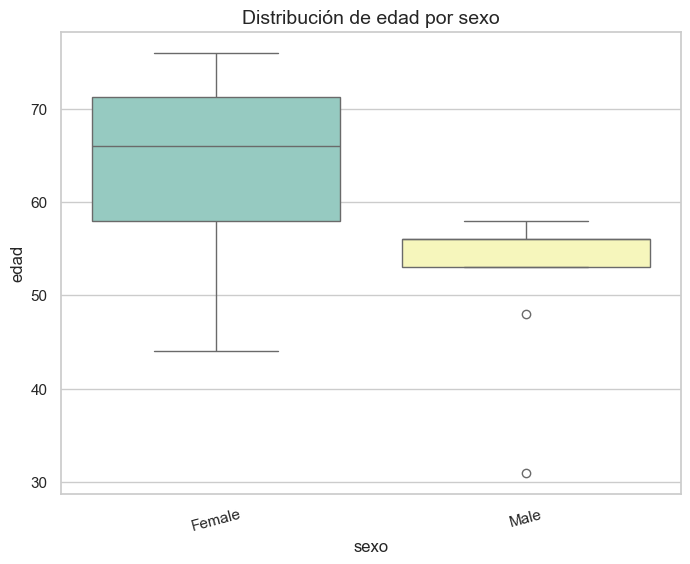

In [7]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='age', palette='Set3')
plt.title("Distribución de edad por sexo", fontsize=14)
plt.ylabel("edad")
plt.xlabel("sexo")
plt.xticks(rotation=15)
plt.show()


Este diagrama de caja muestra la distribución de la edad según el sexo y permite comparar visualmente la mediana, el rango intercuartílico y los valores atípicos en cada grupo.

Para el grupo femenino:La mediana de edad es notablemente más alta, situándose alrededor de los 65 años. El rango intercuartílico (Q1 a Q3) va aproximadamente de 57 a 73 años, lo que indica una mayor dispersión en las edades.También se observa una mayor amplitud general en las edades, incluyendo edades mínimas cercanas a 44 años y máximas cercanas a 76 años.No se presentan valores atípicos.

Para el grupo masculino:La mediana es considerablemente menor, alrededor de los 55 años. Las edades están mucho más concentradas, con un rango intercuartílico entre 53 y 57 años, lo que indica menor variabilidad.Hay presencia de valores atípicos, incluyendo una observación por debajo de los 35 años y otra por debajo de los 50 años, lo que sugiere algunos casos fuera del patrón general del grupo.

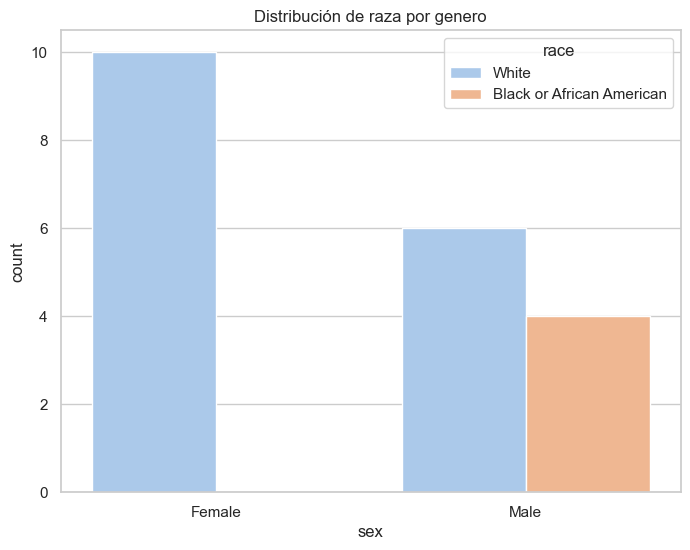

In [8]:
# Gráfico de barras agrupadas
plt.figure(figsize=(8,6))
sns.countplot(data=df2, x="sex", hue="race", palette="pastel")
plt.title("Distribución de raza por genero")
plt.show()

Para el grupo femenino:
Todas las mujeres pertenecen a la categoría "White", con un total de 10 observaciones. No se registran mujeres dentro del grupo racial "Black or African American".

Para el grupo masculino:
Se observa una mayor diversidad en la distribución racial. Hay 6 hombres clasificados como "White" y 4 hombres como "Black or African American". Esto indica que, dentro del grupo masculino, hay una mayor variabilidad racial en comparación con el femenino.

Comparación general:

La categoría "White" está presente en ambos géneros, siendo más frecuente en mujeres.

La categoría "Black or African American" aparece exclusivamente en hombres, representando el 40% del grupo masculino.



#### Analisis de caracteristicas fisicas

/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/868853861.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='sex', y='bmi_kg/m^2', palette='Set2')


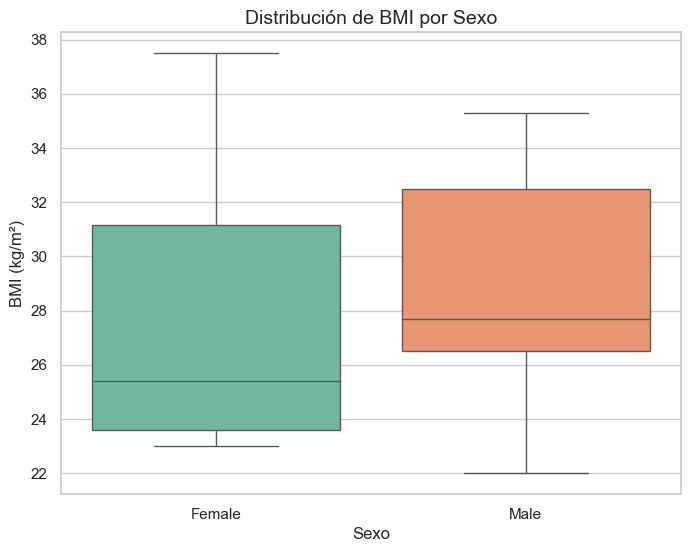

In [9]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='bmi_kg/m^2', palette='Set2')
plt.title("Distribución de BMI por Sexo", fontsize=14)
plt.ylabel("BMI (kg/m²)")
plt.xlabel("Sexo")
plt.show()

Para el grupo femenino:La mediana del BMI se ubica en torno a los 25.5 kg/m², cerca del límite entre peso normal y sobrepeso según criterios estándar. El rango intercuartílico va desde aproximadamente 23 a 31, lo que indica una dispersión moderada de valores. Existen valores más altos cercanos a 37.5, lo que sugiere algunos casos con obesidad, pero sin presencia de valores atípicos marcados por fuera del rango.

Para el grupo masculino: La mediana del BMI es algo más elevada, alrededor de 28 kg/m², dentro del rango correspondiente a sobrepeso. El rango intercuartílico va desde aproximadamente 26 a 32, con valores extremos cercanos a 35 kg/m². El rango inferior llega a unos 22 kg/m², pero sin presencia clara de outliers, lo que indica una distribución más contenida y simétrica.

/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/3371574219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df2, x='race', y='height_centimeters', palette='Set3')


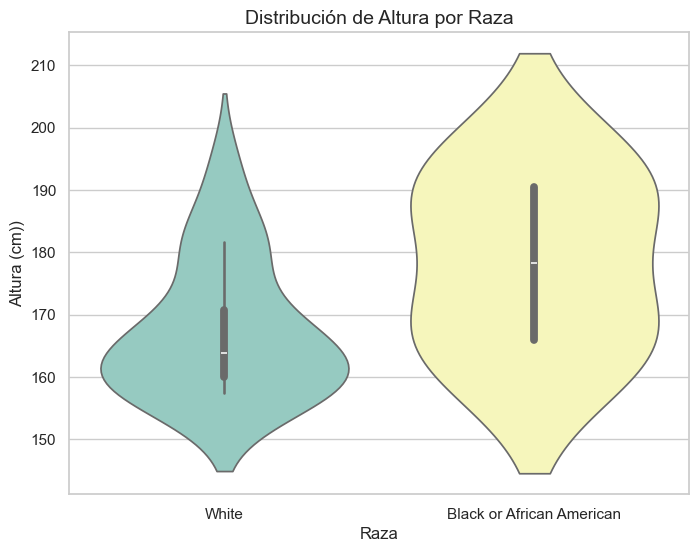

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df2, x='race', y='height_centimeters', palette='Set3')
plt.title("Distribución de Altura por Raza", fontsize=14)
plt.ylabel("Altura (cm))")
plt.xlabel("Raza")
plt.show()

Grupo "White":La mayoría de las observaciones se concentran en torno a los 160–170 cm, con una mediana ligeramente por encima de los 162 cm. La distribución tiene una forma más compacta, con menor dispersión en los valores extremos, aunque se observan algunas alturas que alcanzan los 180 cm o más. La forma del violín indica que las alturas están relativamente agrupadas, con una distribución más simétrica.

Grupo "Black or African American": La mediana es mayor, posicionándose alrededor de los 178 cm, lo que indica que en este grupo los individuos tienden a ser más altos. La distribución presenta mayor dispersión vertical, cubriendo un rango más amplio que va desde aproximadamente 160 cm hasta 200 cm o más. La forma del violín sugiere una distribución bimodal o más aplanada, con varios rangos de altura representados con frecuencias similares.

/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/1425745677.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='sex', y='weight_kilograms', palette='Set1')


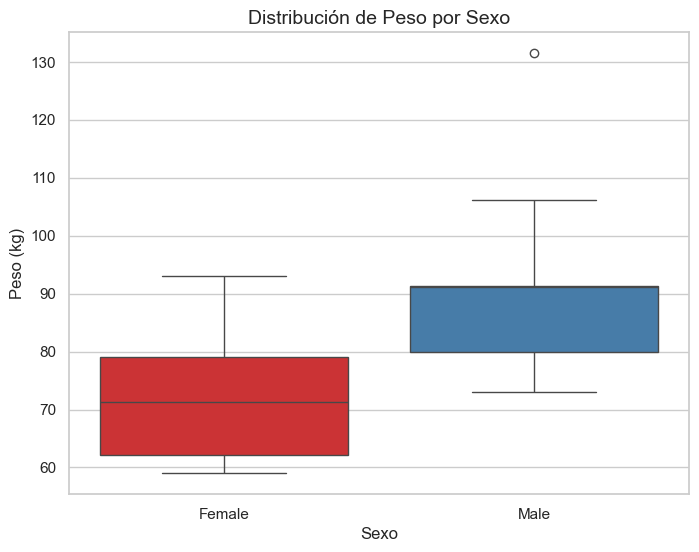

In [11]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df2, x='sex', y='weight_kilograms', palette='Set1')
plt.title("Distribución de Peso por Sexo", fontsize=14)
plt.ylabel("Peso (kg)")
plt.xlabel("Sexo")
plt.show()

Para el grupo femenino: La mediana del peso se encuentra alrededor de los 70 kg. El rango intercuartílico va aproximadamente de 62 a 78 kg, con una dispersión moderada.El peso mínimo ronda los 59 kg, y el máximo se aproxima a los 93 kg, sin presencia de valores atípicos extremos.

Para el grupo masculino:La mediana es más alta, cercana a los 90 kg, lo que indica un peso promedio mayor en comparación con el grupo femenino.El rango intercuartílico se ubica entre 80 y 95 kg, pero hay un valor atípico notable, que supera los 130 kg. Este outlier indica un caso excepcional de peso considerablemente por encima del resto de los registros.



#### Analisis de Anatoimia

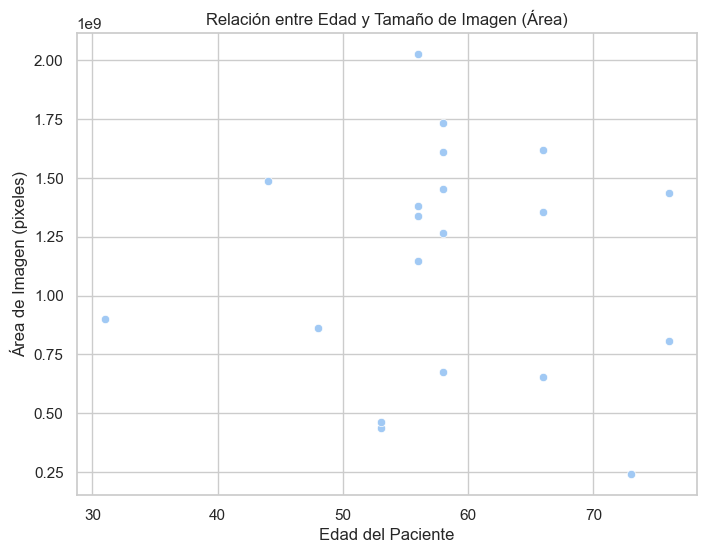

In [12]:
df2['image_area'] = df2['width_pixels'] * df2['height_pixels']

plt.figure(figsize=(8,6))
sns.scatterplot(data=df2, x='age', y='image_area')
plt.title('Relación entre Edad y Tamaño de Imagen (Área)')
plt.xlabel('Edad del Paciente')
plt.ylabel('Área de Imagen (pixeles)')
plt.show()

Observaciones generales:

El área de las imágenes varía ampliamente, con valores que oscilan entre aproximadamente 2.5 × 10⁸ y 2.0 × 10⁹ píxeles. Las edades se distribuyen entre los 30 y 75 años, con mayor concentración de puntos entre los 50 y 65 años, lo cual coincide con lo observado en gráficos anteriores.

Tendencia visual:No se identifica una relación lineal clara entre edad y tamaño de imagen.A cualquier edad, es posible encontrar imágenes tanto pequeñas como grandes. Por ejemplo, hay imágenes de gran área asociadas tanto a personas de 45 años como a personas de más de 65.Se aprecian agrupaciones verticales (mismo valor de edad con diferentes áreas), lo que sugiere que múltiples individuos de la misma edad tienen imágenes de tamaño distinto.

In [13]:
correlacion = df2['age'].corr(df2['image_area'])
print(f"Coeficiente de correlación: {correlacion:.2f}")

Coeficiente de correlación: -0.04


/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/4184766052.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='laterality', y='percent_cortex', palette='Set2')
/var/folders/k9/_sfb2dlj32z_v_srr2ny3qnm0000gn/T/ipykernel_11386/4184766052.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x='laterality', y='percent_medulla', palette='Set3')


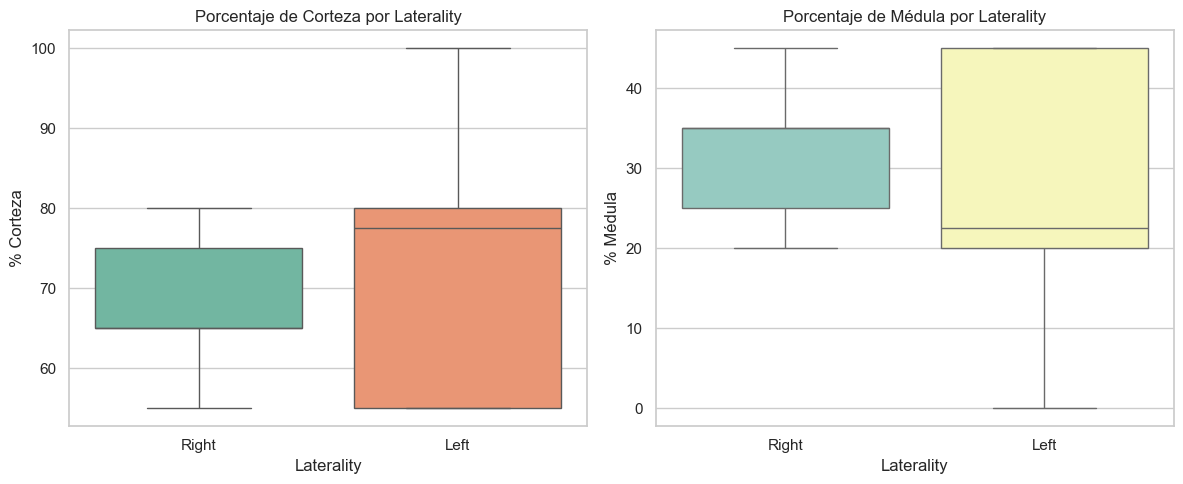

In [14]:
plt.figure(figsize=(12,5))

# Comparar percent_cortex
plt.subplot(1, 2, 1)
sns.boxplot(data=df2, x='laterality', y='percent_cortex', palette='Set2')
plt.title('Porcentaje de Corteza por Laterality')
plt.ylabel('% Corteza')
plt.xlabel('Laterality')

# Comparar percent_medulla
plt.subplot(1, 2, 2)
sns.boxplot(data=df2, x='laterality', y='percent_medulla', palette='Set3')
plt.title('Porcentaje de Médula por Laterality')
plt.ylabel('% Médula')
plt.xlabel('Laterality')

plt.tight_layout()
plt.show()

El lado izquierdo presenta mayor variabilidad tanto en el porcentaje de corteza como en el de médula. La mediana de porcentaje de corteza es ligeramente mayor en el lado izquierdo, mientras que la de porcentaje de médula es menor en el lado izquierdo. Esta relación es coherente: a mayor porcentaje de corteza, menor porcentaje de médula, ya que ambas componentes suman el área total.



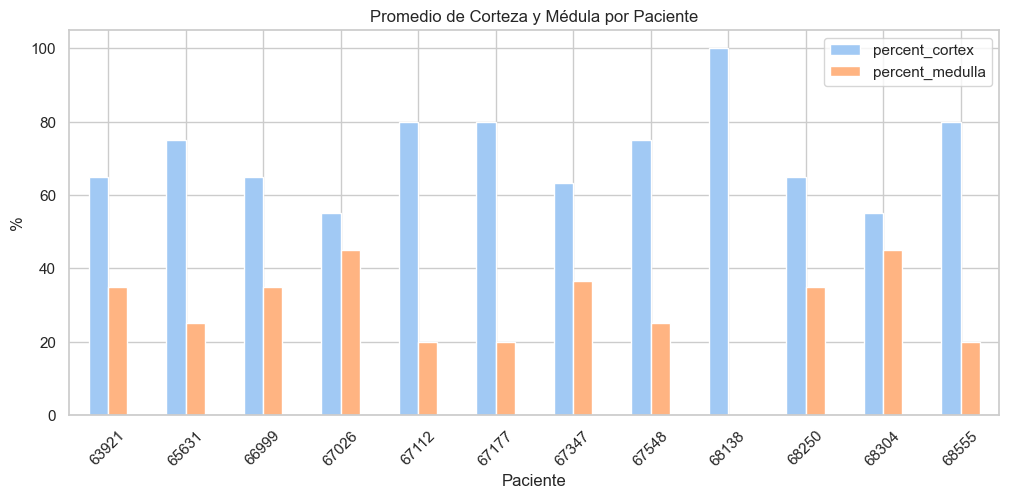

In [15]:
df2[['patient_number', 'percent_cortex', 'percent_medulla']].groupby('patient_number').mean().plot.bar(figsize=(12,5))
plt.title('Promedio de Corteza y Médula por Paciente')
plt.ylabel('%')
plt.xlabel('Paciente')
plt.xticks(rotation=45)
plt.show()

En la mayoría de los pacientes, el porcentaje de corteza es considerablemente mayor que el de médula.Los valores de corteza suelen oscilar entre 55% y 100%, mientras que los de médula se encuentran generalmente entre 20% y 45%.El paciente 68138 destaca con un porcentaje de corteza cercano al 100%, lo que implica un porcentaje de médula muy bajo en comparación con los demás.Pacientes como 67026 y 68304 muestran una mayor proporción de médula (cerca del 45%), indicando un balance más cercano entre corteza y médula. Los pacientes 67112 y 67177 tienen porcentajes de corteza elevados (superiores al 80%) y porcentajes de médula relativamente bajos (cercanos al 20%).

#### Visualizacion de imagenes

In [16]:
im1 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/afa5e8098.tiff'
json1 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/afa5e8098-anatomical-structure.json'
json12 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/afa5e8098.json'


im2 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/2f6ecfcdf.tiff'
json2 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/2f6ecfcdf-anatomical-structure.json'
json22 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/2f6ecfcdf.json'

im3 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/b2dc8411c.tiff'
json3 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/b2dc8411c-anatomical-structure.json'
json32 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/b2dc8411c.json'

im4 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/0486052bb.tiff'
json4 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/0486052bb-anatomical-structure.json'
json42 = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train/0486052bb.json'

/opt/miniconda3/envs/ml_seg/lib/python3.9/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


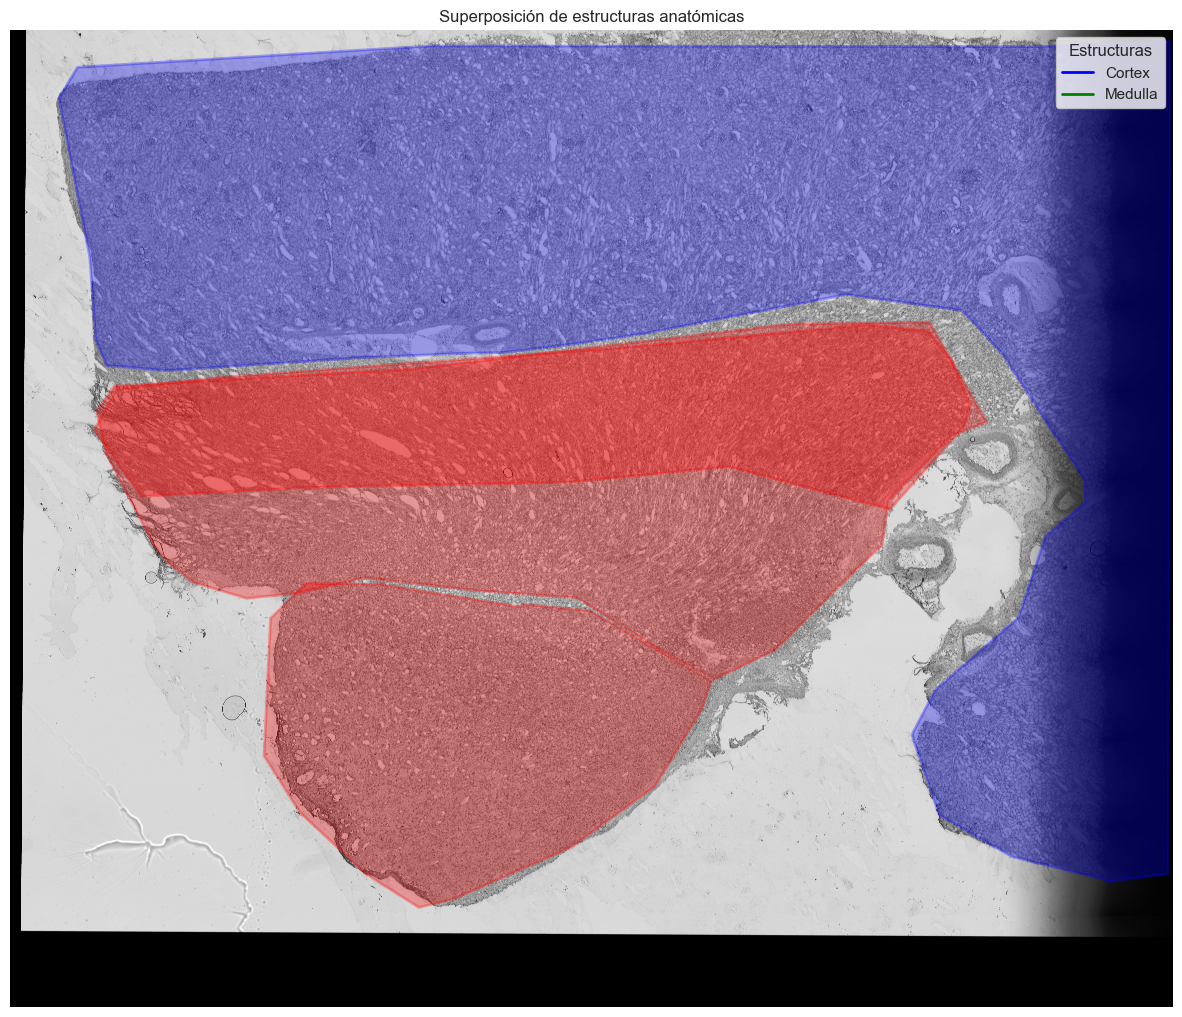

In [17]:
import rasterio
from rasterio.plot import show
from matplotlib.lines import Line2D

# === Leer imagen TIFF ===
with rasterio.open(im1) as src:
    img = src.read(1)
    transform = src.transform  # opcional si quieres georreferenciación

# === Leer anotaciones JSON ===
with open(json1, 'r') as f:
    data = json.load(f)

# === Colores por clase ===
color_map = {
    "Cortex": "blue",
    "Medulla": "green"
}

# === Visualización ===
fig, ax = plt.subplots(figsize=(15, 15))
show(img, ax=ax, cmap='gray')  # Mostrar imagen TIFF

# Dibujar polígonos
for feature in data:
    coords = feature['geometry']['coordinates'][0]
    tipo = feature['properties']['classification']['name']
    color = color_map.get(tipo, "red")  # Color por defecto: rojo

    poly = Polygon(coords, closed=True, edgecolor=color, fill=True,
                   facecolor=color, alpha=0.3, linewidth=2, label=tipo)
    ax.add_patch(poly)

# Eliminar duplicados en la leyenda
handles = [
    Line2D([0], [0], color='blue', label='Cortex', linewidth=2),
    Line2D([0], [0], color='green', label='Medulla', linewidth=2)
]
ax.legend(handles=handles, title="Estructuras", loc="upper right")
ax.set_title("Superposición de estructuras anatómicas")
ax.axis('off')
plt.show()

La imagen presenta una superposición de estructuras anatómicas sobre una muestra histológica, permitiendo visualizar de forma clara las regiones diferenciadas de corteza (cortex) y médula (medulla) dentro del tejido.

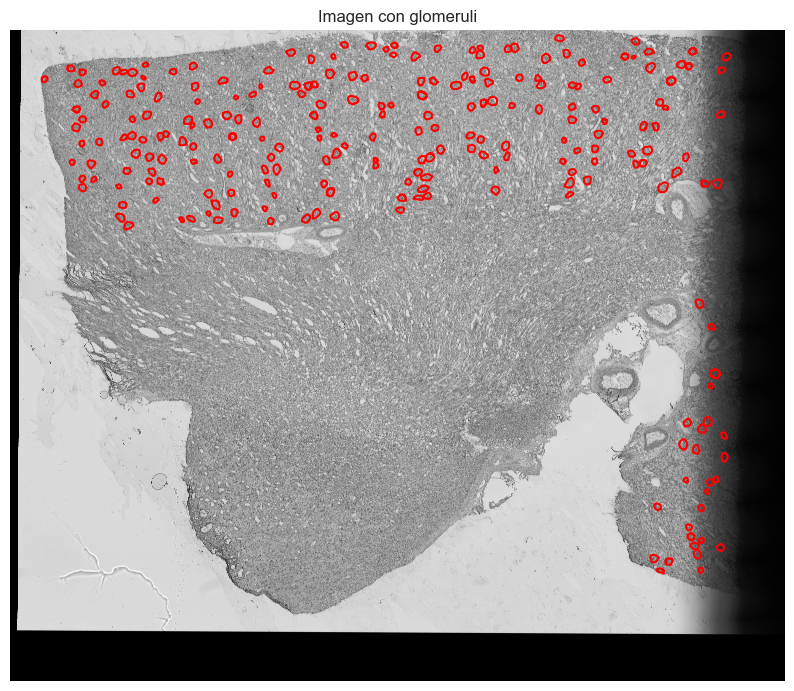

In [18]:
from matplotlib.patches import Polygon

# Cargar anotaciones de glomerulus
with open(json12) as f:
    data_glom = json.load(f)

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Imagen con glomeruli')

# Dibujar los glomeruli en rojo
for feature in data_glom:
    if feature['properties']['classification']['name'].lower() == "glomerulus":
        coords = feature['geometry']['coordinates'][0]
        poly = Polygon(coords, closed=True, edgecolor='red', fill=False, linewidth=1.5)
        plt.gca().add_patch(poly)

plt.show()


La imagen muestra una visualización de glomérulos identificados mediante marcas en color rojo, superpuestos sobre una muestra histológica en escala de grises. Los glomérulos se encuentran distribuidos principalmente en la región superior de la muestra, lo que corresponde a la corteza renal.

Este patrón de distribución es coherente con la anatomía del riñón, ya que los glomérulos se localizan exclusivamente en la corteza y no en la médula. No se observan glomérulos en las regiones más profundas del tejido, lo cual confirma que la detección está alineada con la organización anatómica esperada.

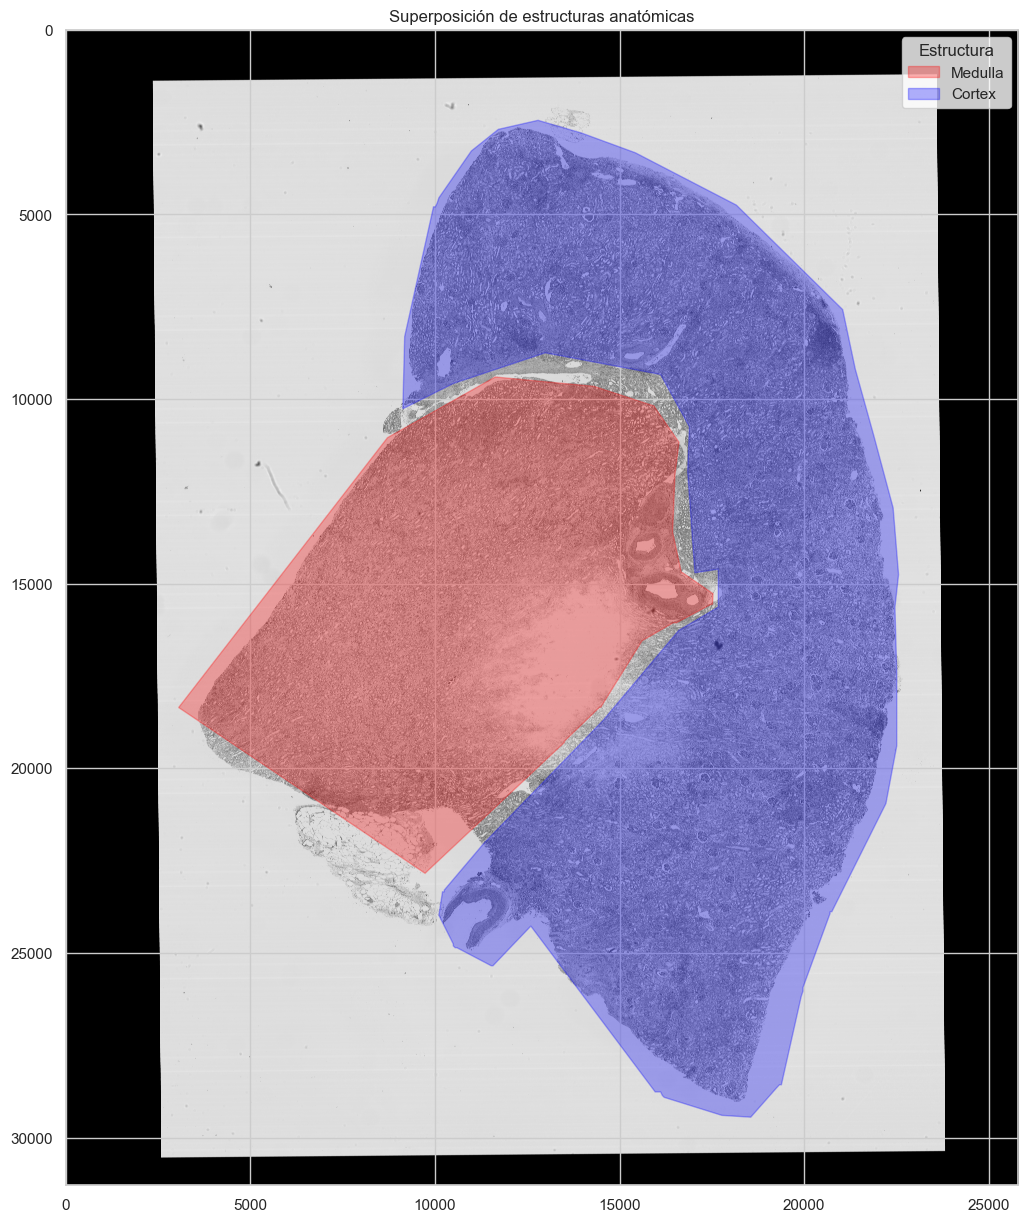

In [19]:
import rasterio
from rasterio.plot import show


# Cargar el TIFF
with rasterio.open(im2) as src:
    img = src.read(1)  # Lee solo el primer canal si es multibanda
    transform = src.transform  # Opcional: para georreferenciación

# Cargar el JSON
with open(json2, 'r') as f:
    data = json.load(f)

# Crear la figura
fig, ax = plt.subplots(figsize=(15, 15))
show(img, ax=ax, cmap='gray')  # Mostrar el TIFF en escala de grises

# Dibujar los polígonos manualmente
color_map = {
    "Medulla": "red",
    "Cortex": "blue"
}

for feature in data:
    coords = feature['geometry']['coordinates'][0]  # Extraer coordenadas del polígono
    classification = feature['properties']['classification']['name']
    color = color_map.get(classification, "gray")

    # Dibujar el polígono
    poly = plt.Polygon(coords, fill=True, color=color, alpha=0.3, label=classification)
    ax.add_patch(poly)

# Añadir leyenda y título
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Estructura")
ax.set_title("Superposición de estructuras anatómicas")
plt.show()

La imagen presenta una superposición de estructuras anatómicas sobre una muestra histológica, permitiendo visualizar de forma clara las regiones diferenciadas de corteza (cortex) y médula (medulla) dentro del tejido.

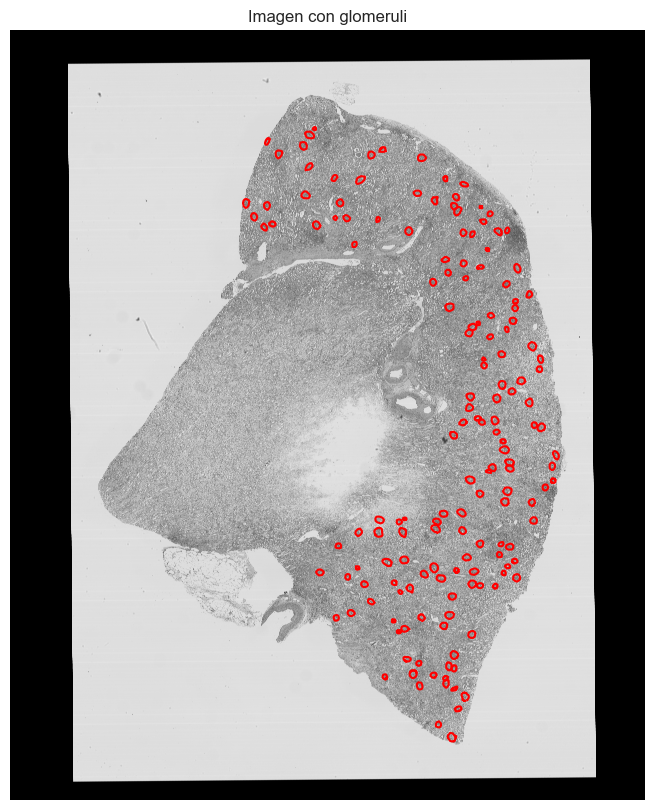

In [20]:
# Cargar anotaciones de glomerulus
with open(json22) as f:
    data_glom = json.load(f)

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Imagen con glomeruli')

# Dibujar los glomeruli en rojo
for feature in data_glom:
    if feature['properties']['classification']['name'].lower() == "glomerulus":
        coords = feature['geometry']['coordinates'][0]
        poly = Polygon(coords, closed=True, edgecolor='red', fill=False, linewidth=1.5)
        plt.gca().add_patch(poly)

plt.show()

La imagen presenta la detección de glomérulos marcada mediante círculos rojos sobre una muestra histológica completa. Los glomérulos se encuentran distribuidos predominantemente en la periferia del tejido, lo cual coincide con la localización de la corteza renal.

Este patrón de distribución confirma que la detección está centrada en la región cortical, donde anatómicamente se localizan los glomérulos. No se observan glomérulos en las zonas centrales, correspondientes a la médula, lo que respalda la precisión del proceso de segmentación y clasificación anatómica previamente realizado.

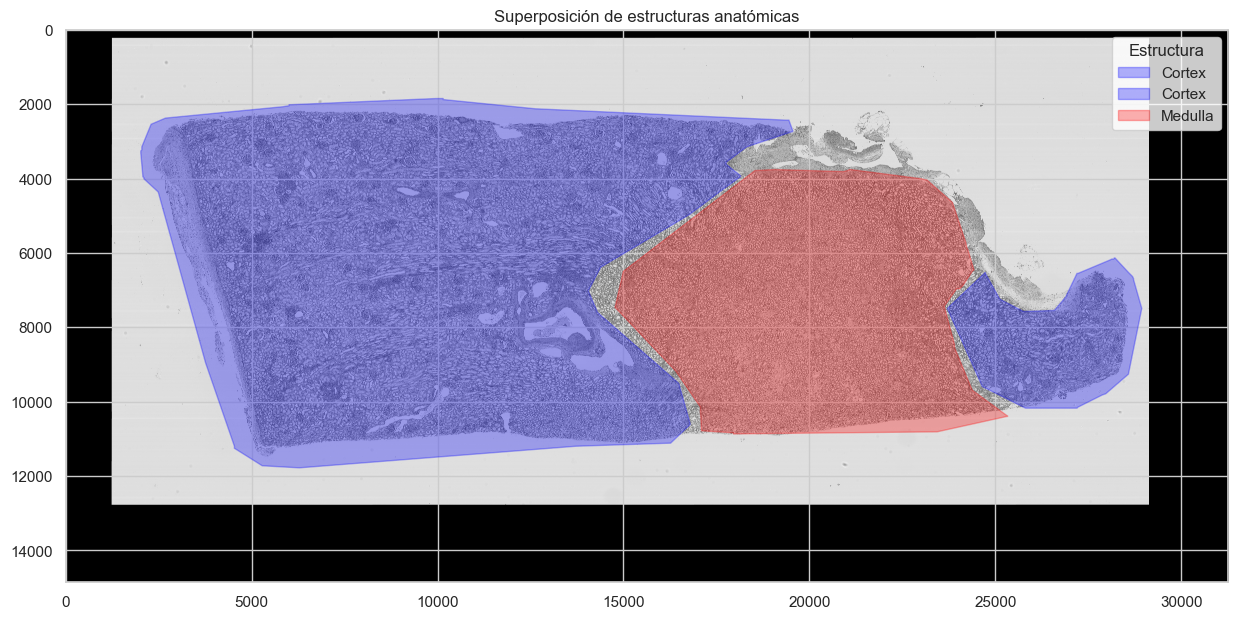

In [21]:
# Cargar el TIFF
with rasterio.open(im3) as src:
    img = src.read(1)  # Lee solo el primer canal si es multibanda
    transform = src.transform  # Opcional: para georreferenciación

# Cargar el JSON
with open(json3, 'r') as f:
    data = json.load(f)

# Crear la figura
fig, ax = plt.subplots(figsize=(15, 15))
show(img, ax=ax, cmap='gray')  # Mostrar el TIFF en escala de grises

# Dibujar los polígonos manualmente
color_map = {
    "Medulla": "red",
    "Cortex": "blue"
}

for feature in data:
    coords = feature['geometry']['coordinates'][0]  # Extraer coordenadas del polígono
    classification = feature['properties']['classification']['name']
    color = color_map.get(classification, "gray")

    # Dibujar el polígono
    poly = plt.Polygon(coords, fill=True, color=color, alpha=0.3, label=classification)
    ax.add_patch(poly)

# Añadir leyenda y título
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Estructura")
ax.set_title("Superposición de estructuras anatómicas")
plt.show()

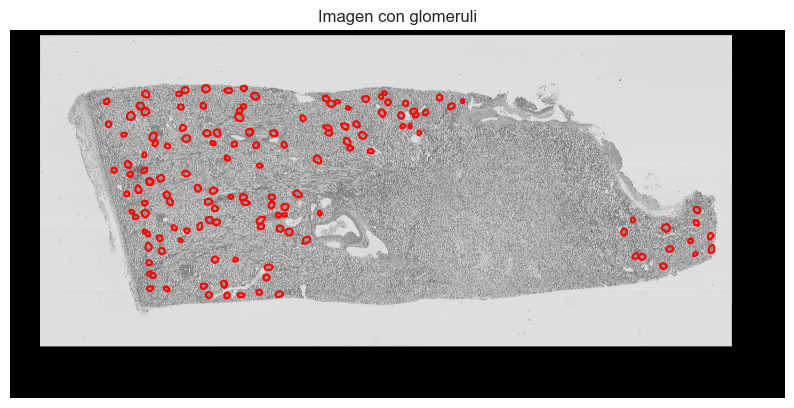

In [22]:
# Cargar anotaciones de glomerulus
with open(json32) as f:
    data_glom = json.load(f)

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Imagen con glomeruli')

# Dibujar los glomeruli en rojo
for feature in data_glom:
    if feature['properties']['classification']['name'].lower() == "glomerulus":
        coords = feature['geometry']['coordinates'][0]
        poly = Polygon(coords, closed=True, edgecolor='red', fill=False, linewidth=1.5)
        plt.gca().add_patch(poly)

plt.show()

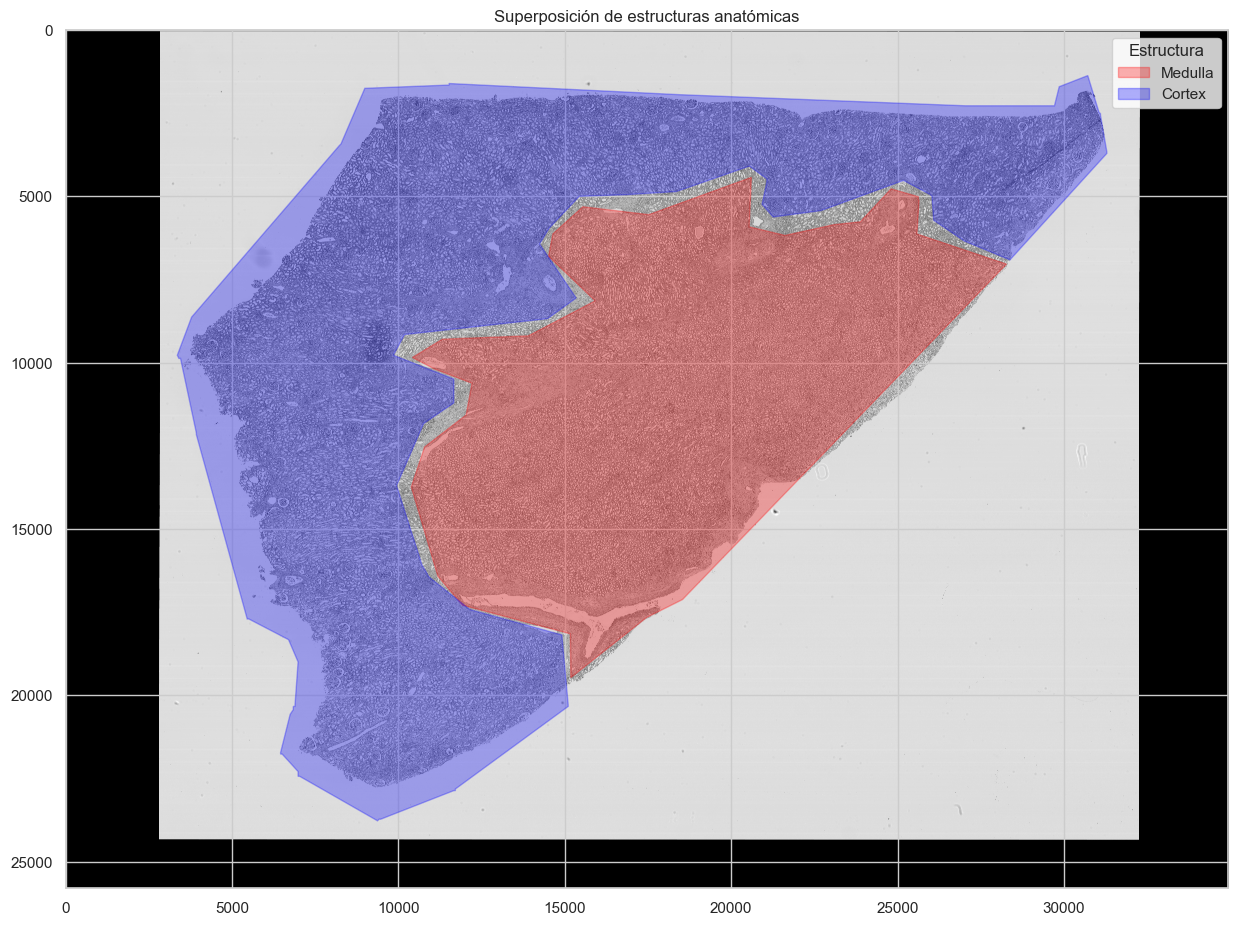

In [23]:
# Cargar el TIFF
with rasterio.open(im4) as src:
    img = src.read(1)  # Lee solo el primer canal si es multibanda
    transform = src.transform  # Opcional: para georreferenciación

# Cargar el JSON
with open(json4, 'r') as f:
    data = json.load(f)

# Crear la figura
fig, ax = plt.subplots(figsize=(15, 15))
show(img, ax=ax, cmap='gray')  # Mostrar el TIFF en escala de grises

# Dibujar los polígonos manualmente
color_map = {
    "Medulla": "red",
    "Cortex": "blue"
}

for feature in data:
    coords = feature['geometry']['coordinates'][0]  # Extraer coordenadas del polígono
    classification = feature['properties']['classification']['name']
    color = color_map.get(classification, "gray")

    # Dibujar el polígono
    poly = plt.Polygon(coords, fill=True, color=color, alpha=0.3, label=classification)
    ax.add_patch(poly)

# Añadir leyenda y título
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Estructura")
ax.set_title("Superposición de estructuras anatómicas")
plt.show()

La imagen presenta una superposición de estructuras anatómicas sobre una muestra histológica, permitiendo visualizar de forma clara las regiones diferenciadas de corteza (cortex) y médula (medulla) dentro del tejido.

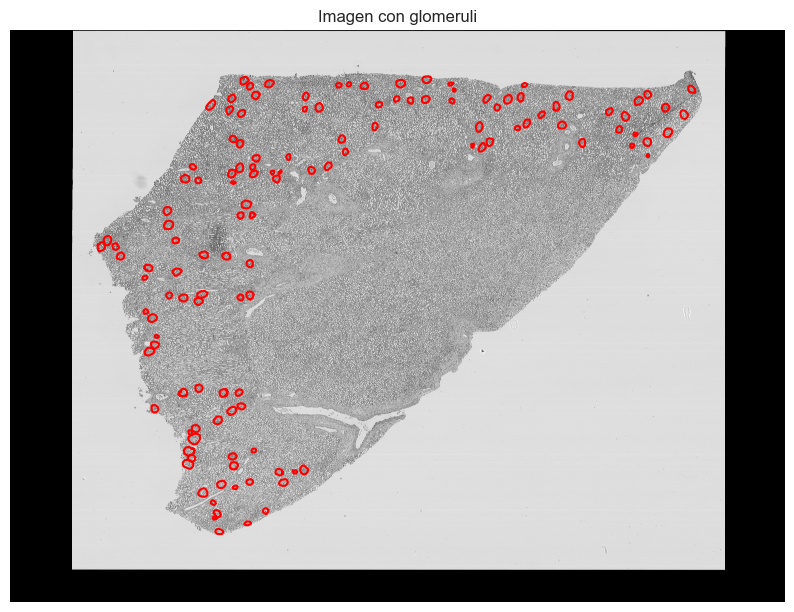

In [24]:
# Cargar anotaciones de glomerulus
with open(json42) as f:
    data_glom = json.load(f)

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Imagen con glomeruli')

# Dibujar los glomeruli en rojo
for feature in data_glom:
    if feature['properties']['classification']['name'].lower() == "glomerulus":
        coords = feature['geometry']['coordinates'][0]
        poly = Polygon(coords, closed=True, edgecolor='red', fill=False, linewidth=1.5)
        plt.gca().add_patch(poly)

plt.show()

La imagen muestra la identificación de glomérulos, destacados mediante círculos rojos, sobre una sección histológica completa. Los glomérulos se encuentran distribuidos en la parte más externa del tejido, lo que corresponde morfológicamente a la zona cortical del riñón.

#### Reprocesamiento de Datos - Máscaras e Imágenes

En la siguiente tabla se puede observar el ID de cada imagen junto con su respectivo encoding.

In [25]:
df3 = pd.read_csv("train.csv")
df3

,id,encoding
0,2f6ecfcdf,296084587 4 296115835 6 296115859 14 296147109...
1,8242609fa,96909968 56 96941265 60 96972563 64 97003861 6...
2,aaa6a05cc,30989109 59 31007591 64 31026074 68 31044556 7...
3,cb2d976f4,78144363 5 78179297 15 78214231 25 78249165 35...
4,b9a3865fc,61271840 4 61303134 13 61334428 22 61365722 30...
5,b2dc8411c,56157731 21 56172571 45 56187411 51 56202252 5...
6,0486052bb,101676003 6 101701785 8 101727568 9 101753351 ...
7,e79de561c,7334642 14 7350821 41 7367001 67 7383180 82 73...
8,095bf7a1f,113277795 21 113315936 53 113354083 87 1133922...
9,54f2eec69,124967057 36 124997425 109 125027828 147 12505...


In [26]:
df_info = df2.copy()
df_info['id'] = df_info['image_file'].str.replace(".tiff", "", regex=False)

# Unir por la columna 'id'
df_merged = df3.merge(df_info[['id', 'height_pixels', 'width_pixels']], on='id', how='left')

df_merged['shape'] = list(zip(df_merged['height_pixels'], df_merged['width_pixels']))
df_merged

,id,encoding,height_pixels,width_pixels,shape
0,2f6ecfcdf,296084587 4 296115835 6 296115859 14 296147109...,31278,25794,"(31278, 25794)"
1,8242609fa,96909968 56 96941265 60 96972563 64 97003861 6...,31299,44066,"(31299, 44066)"
2,aaa6a05cc,30989109 59 31007591 64 31026074 68 31044556 7...,18484,13013,"(18484, 13013)"
3,cb2d976f4,78144363 5 78179297 15 78214231 25 78249165 35...,34940,49548,"(34940, 49548)"
4,b9a3865fc,61271840 4 61303134 13 61334428 22 61365722 30...,31295,40429,"(31295, 40429)"
5,b2dc8411c,56157731 21 56172571 45 56187411 51 56202252 5...,14844,31262,"(14844, 31262)"
6,0486052bb,101676003 6 101701785 8 101727568 9 101753351 ...,25784,34937,"(25784, 34937)"
7,e79de561c,7334642 14 7350821 41 7367001 67 7383180 82 73...,16180,27020,"(16180, 27020)"
8,095bf7a1f,113277795 21 113315936 53 113354083 87 1133922...,38160,39000,"(38160, 39000)"
9,54f2eec69,124967057 36 124997425 109 125027828 147 12505...,30440,22240,"(30440, 22240)"


En la tabla anterior se presentan los píxeles (altura y ancho) combinados en una sola columna denominada Shape. Con la siguiente función, se realiza el cálculo de la máscara correspondiente a cada ID.

In [27]:
def rle_decode(mask_rle, shape):
    height, width = shape
    mask = np.zeros(height * width, dtype=np.uint8)

    if mask_rle == "":  # Manejo de encodings vacíos
        return mask.reshape(height, width)

    # Convertir el string a array de enteros
    array = np.asarray([int(x) for x in mask_rle.split()])

    # Los valores pares (0, 2, 4, ...) son las posiciones de inicio
    # Los valores impares (1, 3, 5, ...) son las longitudes de los segmentos
    starts = array[0::2] - 1  # RLE generalmente usa indexación desde 1
    lengths = array[1::2]

    # Configurar los valores en la máscara
    for start, length in zip(starts, lengths):
        mask[start:start + length] = 1

    # Remodelar la máscara a las dimensiones de la imagen
    return mask.reshape(shape)

# Añadir una columna con las máscaras decodificadas
df_merged['mask'] = df_merged.apply(
    lambda row: rle_decode(row['encoding'], row['shape']),
    axis=1
)


In [28]:
df_merged

,id,encoding,height_pixels,width_pixels,shape,mask
0,2f6ecfcdf,296084587 4 296115835 6 296115859 14 296147109...,31278,25794,"(31278, 25794)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,8242609fa,96909968 56 96941265 60 96972563 64 97003861 6...,31299,44066,"(31299, 44066)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,aaa6a05cc,30989109 59 31007591 64 31026074 68 31044556 7...,18484,13013,"(18484, 13013)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,cb2d976f4,78144363 5 78179297 15 78214231 25 78249165 35...,34940,49548,"(34940, 49548)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,b9a3865fc,61271840 4 61303134 13 61334428 22 61365722 30...,31295,40429,"(31295, 40429)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
5,b2dc8411c,56157731 21 56172571 45 56187411 51 56202252 5...,14844,31262,"(14844, 31262)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
6,0486052bb,101676003 6 101701785 8 101727568 9 101753351 ...,25784,34937,"(25784, 34937)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
7,e79de561c,7334642 14 7350821 41 7367001 67 7383180 82 73...,16180,27020,"(16180, 27020)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
8,095bf7a1f,113277795 21 113315936 53 113354083 87 1133922...,38160,39000,"(38160, 39000)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
9,54f2eec69,124967057 36 124997425 109 125027828 147 12505...,30440,22240,"(30440, 22240)","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


Finalmente, se obtiene la tabla final con la máscara correspondiente a cada ID.

In [ ]:
from sklearn.model_selection import train_test_split
from tqdm import tqdm


# Permitir abrir imágenes muy grandes
Image.MAX_IMAGE_PIXELS = None

# CONFIG
IMG_HEIGHT, IMG_WIDTH = 256, 256
BATCH_SIZE = 2
EPOCHS = 5
IMAGES_DIR = '/Users/user/Desktop/Maestria 2025/Maestria Uninorte/Primer semestre 2025/Machine Learning/train'
df_train, df_val = train_test_split(df_merged, test_size=0.2, random_state=42)

En el código anterior se definieron los parámetros para el redimensionamiento de las imágenes, así como la partición de los datos en conjuntos de entrenamiento y prueba. Por otro lado, en el siguiente código se presenta la clase utilizada para realizar dicho resize, empleando la librería Keras.

In [31]:
# Data Generator estilo flow_from_dataframe
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, images_dir, batch_size=BATCH_SIZE, img_size=(IMG_HEIGHT, IMG_WIDTH), shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.images_dir = images_dir
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataframe))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.dataframe) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.dataframe.iloc[batch_indexes]

        images, masks = [], []
        for _, row in batch_df.iterrows():
            image_id = row['id']
            image_path = os.path.join(self.images_dir, image_id + '.tiff')

            try:
                image = Image.open(image_path)
                image = np.array(image)
                if image.ndim == 2:
                    image = np.stack([image]*3, axis=-1)
                elif image.shape[0] == 3 and image.shape[1] > 100:
                    image = np.transpose(image, (1, 2, 0))
                image = image.astype(np.float32) / 255.0
            except:
                image = np.zeros((self.img_size[0], self.img_size[1], 3), dtype=np.float32)

            try:
                mask_array = json.loads(row['mask'])
                mask = np.array(mask_array, dtype=np.float32)
                if mask.ndim == 2:
                    mask = np.expand_dims(mask, axis=-1)
            except:
                mask = np.zeros((self.img_size[0], self.img_size[1], 1), dtype=np.float32)

            image = tf.image.resize(image, self.img_size)
            mask = tf.image.resize(mask, self.img_size, method='nearest')

            images.append(image)
            masks.append(mask)

        return np.stack(images), np.stack(masks)

# Crear generadores
train_generator = DataGenerator(df_train, IMAGES_DIR)
val_generator = DataGenerator(df_val, IMAGES_DIR)

A continuación, se diseñarán los modelos que se implementarán para la segmentación del conjunto de datos de entrenamiento.

#### Modelo U-net

In [32]:
# Definir U-Net
def build_unet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = tf.keras.Input(shape=input_shape)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    return models.Model(inputs=[inputs], outputs=[outputs])

In [33]:
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# Compilar modelo
model = build_unet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
]

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 16, 16,    │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 16, 16,    │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 32, 32,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo V-Net

In [34]:
# Definir V-Net (versión simplificada para 2D)
def build_vnet(input_shape=(512, 512, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    # Downsampling path
    c1 = layers.Conv2D(16, (5, 5), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(32, (5, 5), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(64, (5, 5), activation='relu', padding='same')(p2)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # Bottleneck
    c4 = layers.Conv2D(128, (5, 5), activation='relu', padding='same')(p3)

    # Upsampling path
    u1 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c4)
    u1 = layers.concatenate([u1, c3])

    u2 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(u1)
    u2 = layers.concatenate([u2, c2])

    u3 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(u2)
    u3 = layers.concatenate([u3, c1])

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(u3)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [35]:
# Compilar modelo
model = build_vnet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 512, 512,  │      1,216 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 256, 256,  │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │     12,832 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     51,264 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 64, 64,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    204,928 │ max_pooling2d_6[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 128, 128,  │     32,832 │ conv2d_22[0][0]   │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 256, 256,  │     16,416 │ concatenate_4[0]… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_6  │ (None, 512, 512,  │      4,112 │ concatenate_5[0]… │
│ (Conv2DTranspose)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 512, 512,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 32)               │            │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 512, 512,  │         33 │ concatenate_6[0]… │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 323,633 (1.23 MB)

 Trainable params: 323,633 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo Seg-Net

In [36]:
# Definir SegNet

def build_segnet(input_shape=(512, 512, 3)):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    p1 = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    p2 = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    p3 = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2DTranspose(256, (3, 3), strides=(2, 2), padding='same', activation='relu')(p3)
    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [37]:
# Compilar modelo
model = build_segnet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 512, 512, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 512, 512, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 256, 256, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 128, 128, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 128, 128, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_7              │ (None, 128, 128, 256)  │       590,080 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 256)  │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_8              │ (None, 256, 256, 128)  │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 256, 256, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_9              │ (None, 512, 512, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 512, 512, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 512, 512, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,878,977 (10.98 MB)

 Trainable params: 2,878,977 (10.98 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo ResUNet

In [38]:
def build_resunet(input_shape=(512, 512, 3)):
    def residual_block(x, filters):
        shortcut = x
        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)

        x = layers.Conv2D(filters, (3, 3), padding='same')(x)
        x = layers.BatchNormalization()(x)

        shortcut = layers.Conv2D(filters, (1, 1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

        x = layers.add([shortcut, x])
        x = layers.Activation('relu')(x)
        return x

    inputs = layers.Input(shape=input_shape)

    # Encoder
    e1 = residual_block(inputs, 64)
    p1 = layers.MaxPooling2D((2, 2))(e1)

    e2 = residual_block(p1, 128)
    p2 = layers.MaxPooling2D((2, 2))(e2)

    e3 = residual_block(p2, 256)
    p3 = layers.MaxPooling2D((2, 2))(e3)

    e4 = residual_block(p3, 512)
    p4 = layers.MaxPooling2D((2, 2))(e4)

    # Bottleneck
    b1 = residual_block(p4, 1024)

    # Decoder
    u1 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, e4])
    d1 = residual_block(u1, 512)

    u2 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(d1)
    u2 = layers.concatenate([u2, e3])
    d2 = residual_block(u2, 256)

    u3 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d2)
    u3 = layers.concatenate([u3, e2])
    d3 = residual_block(u3, 128)

    u4 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d3)
    u4 = layers.concatenate([u4, e1])
    d4 = residual_block(u4, 64)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(d4)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [39]:
# Compilar modelo
model = build_resunet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 512, 512,  │      1,792 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512, 512,  │        256 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 512, 512,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 512, 512,  │        256 │ input_layer_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 512, 512,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 512, 512,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 512, 512,  │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 256, 256,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_37[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 256, 256,  │      8,320 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 256, 256,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        512 │ conv2d_39[0][0] 

 Total params: 32,462,849 (123.84 MB)

 Trainable params: 32,445,185 (123.77 MB)

 Non-trainable params: 17,664 (69.00 KB)

#### Modelo Attention U-Net

In [40]:
def build_attention_unet(input_shape=(512, 512, 3)):
    def attention_gate(x, g, inter_channels):
        theta_x = layers.Conv2D(inter_channels, (2, 2), strides=(2, 2), padding='same')(x)
        phi_g = layers.Conv2D(inter_channels, (1, 1), padding='same')(g)
        add = layers.add([theta_x, phi_g])
        act = layers.Activation('relu')(add)
        psi = layers.Conv2D(1, (1, 1), padding='same')(act)
        psi = layers.Activation('sigmoid')(psi)
        upsample_psi = layers.UpSampling2D(size=(2, 2))(psi)
        upsample_psi = layers.multiply([x, upsample_psi])
        return upsample_psi

    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)

    # Decoder with Attention
    g4 = attention_gate(c4, c5, 512)
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, g4])

    g3 = attention_gate(c3, u6, 256)
    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(u6)
    u7 = layers.concatenate([u7, g3])

    g2 = attention_gate(c2, u7, 128)
    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(u7)
    u8 = layers.concatenate([u8, g2])

    g1 = attention_gate(c1, u8, 64)
    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(u8)
    u9 = layers.concatenate([u9, g1])

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(u9)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [41]:
# Compilar modelo
model = build_attention_unet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_62 (Conv2D)  │ (None, 512, 512,  │      1,792 │ input_layer_4[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_14    │ (None, 256, 256,  │          0 │ conv2d_62[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_63 (Conv2D)  │ (None, 256, 256,  │     73,856 │ max_pooling2d_14… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_15    │ (None, 128, 128,  │          0 │ conv2d_63[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_64 (Conv2D)  │ (None, 128, 128,  │    295,168 │ max_pooling2d_15… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_16    │ (None, 64, 64,    │          0 │ conv2d_64[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_65 (Conv2D)  │ (None, 64, 64,    │  1,180,160 │ max_pooling2d_16… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_17    │ (None, 32, 32,    │          0 │ conv2d_65[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_66 (Conv2D)  │ (None, 32, 32,    │  4,719,616 │ max_pooling2d_17… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_67 (Conv2D)  │ (None, 32, 32,    │  1,049,088 │ conv2d_65[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_68 (Conv2D)  │ (None, 32, 32,    │    524,800 │ conv2d_66[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 32, 32,    │          0 │ conv2d_67[0][0],  │
│                     │ 512)              │            │ conv2d_68[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 32, 32,    │          0 │ add_9[0][0]       │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_69 (Conv2D)  │ (None, 32, 32, 1) │        513 │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 32, 32, 1) │          0 │ conv2d_69[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64, 1) │          0 │ activation_19[0]… │
│ (UpSampling2D)      │                   │            │                 

 Total params: 12,008,965 (45.81 MB)

 Trainable params: 12,008,965 (45.81 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo FCN-8s (Fully Convolutional Network)

In [42]:
def build_fcn(input_shape=(512, 512, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same', activation='relu')(x)
    x = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [43]:
model = build_fcn()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 512, 512, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 256, 256, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 256, 256, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 128, 128, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 128, 128, 256)  │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 64, 64, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 64, 64, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_18             │ (None, 128, 128, 256)  │       524,544 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_19             │ (None, 256, 256, 128)  │       131,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_20             │ (None, 512, 512, 64)   │        32,832 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_84 (Conv2D)              │ (None, 512, 512, 1)    │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,239,617 (8.54 MB)

 Trainable params: 2,239,617 (8.54 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo Swin U-Net

In [44]:
def build_swin_unet(input_shape=(512, 512, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    return models.Model(inputs=[inputs], outputs=[outputs])

In [45]:
model = build_swin_unet()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 512, 512,  │      1,792 │ input_layer_6[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 512, 512,  │        128 │ conv2d_85[0][0]   │
│ (LayerNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 512, 512,  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │ 64)               │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 512, 512,  │     73,856 │ multi_head_atten… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512, 512,  │        256 │ conv2d_86[0][0]   │
│ (LayerNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 512, 512,  │    131,968 │ layer_normalizat… │
│ (MultiHeadAttentio… │ 128)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_87 (Conv2D)  │ (None, 512, 512,  │    295,168 │ multi_head_atten… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 512, 512,  │        512 │ conv2d_87[0][0]   │
│ (LayerNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 512, 512,  │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │ 256)              │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_88 (Conv2D)  │ (None, 512, 512,  │    295,040 │ multi_head_atten… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 1024,      │          0 │ conv2d_88[0][0]   │
│ (UpSampling2D)      │ 1024, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_89 (Conv2D)  │ (None, 1024,      │     73,792 │ up_sampling2d_4[… │
│                     │ 1024, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 2048,      │          0 │ conv2d_89[0][0]   │
│ (UpSampling2D)      │ 2048, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_90 (Conv2D)  │ (None, 2048,      │         65 │ up_sampling2d_5[… │
│                     │ 2048, 1)          │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,202,113 (4.59 MB)

 Trainable params: 1,202,113 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

#### Modelo DeepLabV3+

In [46]:
def build_deeplabv3plus(input_shape=(512, 512, 3)):
    base_model = tf.keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

    # Atrous Spatial Pyramid Pooling (ASPP)
    x = base_model.output
    x = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    return models.Model(inputs=base_model.input, outputs=outputs)

In [47]:
model = build_deeplabv3plus()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 256, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 256, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 256, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 256, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 256, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 257, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 128, 128,  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 128, 128,  │      2,304 │ block_1_depthwis

 Total params: 2,882,625 (11.00 MB)

 Trainable params: 2,847,745 (10.86 MB)

 Non-trainable params: 34,880 (136.25 KB)

#### Modelo PSNet

In [48]:
def build_pspnet(input_shape=(512, 512, 3)):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Pyramid Pooling Module (PPM)
    pool1 = layers.AveragePooling2D(pool_size=(60, 60))(x)
    pool1 = layers.Conv2D(64, (1, 1), activation='relu', padding='same')(pool1)
    pool1 = layers.UpSampling2D(size=(60, 60), interpolation='bilinear')(pool1)

    pool2 = layers.AveragePooling2D(pool_size=(30, 30))(x)
    pool2 = layers.Conv2D(64, (1, 1), activation='relu', padding='same')(pool2)
    pool2 = layers.UpSampling2D(size=(30, 30), interpolation='bilinear')(pool2)

    pool3 = layers.AveragePooling2D(pool_size=(20, 20))(x)
    pool3 = layers.Conv2D(64, (1, 1), activation='relu', padding='same')(pool3)
    pool3 = layers.UpSampling2D(size=(20, 20), interpolation='bilinear')(pool3)

    pool4 = layers.AveragePooling2D(pool_size=(10, 10))(x)
    pool4 = layers.Conv2D(64, (1, 1), activation='relu', padding='same')(pool4)
    pool4 = layers.UpSampling2D(size=(10, 10), interpolation='bilinear')(pool4)

    x = layers.concatenate([x, pool1, pool2, pool3, pool4])
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)

    x = layers.UpSampling2D(size=(4, 4), interpolation='bilinear')(x)
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(x)

    return models.Model(inputs=inputs, outputs=outputs)


In [49]:
model = build_deeplabv3plus()
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_unet_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)]

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 256, 256,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 256, 256,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 256, 256,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 256, 256,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 256, 256,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 256, 256,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 256, 256,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 256, 256,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 257, 257,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 128, 128,  │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 128, 128,  │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 128, 128,  │      2,304 │ block_1_depthwis

 Total params: 2,882,625 (11.00 MB)

 Trainable params: 2,847,745 (10.86 MB)

 Non-trainable params: 34,880 (136.25 KB)

### Entrenamiento y Evaluacion de los modelos

En el siguiente apartado se presenta el entrenamiento y evaluación de los modelos de segmentación de manera estructurada y replicable. Para lograrlo, se ha desarrollado una función que encapsula todo el proceso de entrenamiento y evaluación de un modelo dado. Esta función primero recibe un modelo, un nombre identificador, los conjuntos de datos de entrenamiento y validación, además de los parámetros de entrenamiento como el número de épocas y los callbacks correspondientes.

Durante su ejecución, la función verifica si existe previamente un archivo .joblib que contenga el historial de entrenamiento asociado al modelo especificado. Si el archivo existe, se carga directamente para evitar repetir el proceso de entrenamiento, haciendo el flujo más eficiente. Si el archivo no existe, el modelo se entrena utilizando los datos provistos y el historial generado se guarda automáticamente en un archivo para su uso futuro. Esto permite optimizar el tiempo de ejecución, especialmente en escenarios donde los experimentos deben reiniciarse varias veces.

Una vez entrenado el modelo o cargado su historial, otra función adicional evalúa su desempeño sobre el conjunto de validación. En esta fase, se calculan métricas esenciales para problemas de segmentación, incluyendo el coeficiente Dice, la Intersección sobre Unión (IoU), la precisión, la sensibilidad (recall), el área bajo la curva ROC (AUC), la precisión balanceada y la distancia de Hausdorff. Esta evaluación proporciona una visión integral del rendimiento de cada modelo en diferentes aspectos de la tarea de segmentación.

Todo este flujo organizado permite aplicar de manera sencilla el mismo procedimiento a diferentes arquitecturas de segmentación, garantizando comparabilidad justa y ordenada entre los resultados obtenidos para cada uno.

```python

from joblib import dump, load
from sklearn.metrics import jaccard_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score
from scipy.spatial.distance import directed_hausdorff

# Función para entrenar y guardar history
def train_and_save_history(model, name, train_dataset, val_dataset, epochs=10, callbacks=None):
    history_file = f'history_{name}.joblib'

    if os.path.exists(history_file):
        history = load(history_file)
        print(f'✅ Historial cargado desde {history_file}.')
    else:
        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=epochs,
            callbacks=callbacks,
            verbose=2
        )
        dump(history.history, history_file)
        print(f'✅ Entrenamiento completado y guardado en {history_file}.')
    return history

# Función para calcular métricas
def evaluate_model(model, val_dataset):
    y_true = []
    y_pred = []

    for batch_images, batch_masks in val_dataset:
        preds = model.predict(batch_images)
        preds_binary = (preds > 0.5).astype(np.uint8)

        y_true.append(batch_masks.numpy().flatten())
        y_pred.append(preds_binary.flatten())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Métricas
    dice = (2 * np.sum(y_true * y_pred)) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)
    iou = jaccard_score(y_true, y_pred, average='binary')
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        auc = np.nan

    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # Hausdorff Distance (primer batch)
    batch_images, batch_masks = next(iter(val_dataset))
    preds_first = model.predict(batch_images)
    preds_first_binary = (preds_first > 0.5).astype(np.uint8)

    true_coords = np.argwhere(batch_masks[0].numpy().squeeze() > 0)
    pred_coords = np.argwhere(preds_first_binary[0].squeeze() > 0)

    if len(true_coords) > 0 and len(pred_coords) > 0:
        hausdorff = max(
            directed_hausdorff(true_coords, pred_coords)[0],
            directed_hausdorff(pred_coords, true_coords)[0]
        )
    else:
        hausdorff = np.nan

    metrics = {
        'Dice': dice,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'AUC': auc,
        'Balanced Accuracy': balanced_acc,
        'Hausdorff Distance': hausdorff
    }

    return metrics

#### Predicciones y desempeno

La función 'evaluate_model_on_test' evalúa un modelo ya entrenado utilizando un conjunto de datos de prueba (test_dataset). Para cada imagen del test, el modelo genera una predicción que se convierte en una máscara binaria. Luego, compara las predicciones con las máscaras verdaderas y calcula métricas de segmentación como Dice, IoU, Precisión, Recall, AUC, Precisión Balanceada y Distancia de Hausdorff. Finalmente, devuelve todas las métricas en un diccionario organizado, permitiendo medir de forma precisa el desempeño final del modelo sobre datos nunca vistos.

```python

def evaluate_model_on_test(model, test_dataset):
    y_true = []
    y_pred = []

    for batch_images, batch_masks in test_dataset:
        preds = model.predict(batch_images)
        preds_binary = (preds > 0.5).astype(np.uint8)

        y_true.append(batch_masks.numpy().flatten())
        y_pred.append(preds_binary.flatten())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Métricas
    dice = (2 * np.sum(y_true * y_pred)) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)
    iou = jaccard_score(y_true, y_pred, average='binary')
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_pred)
    except ValueError:
        auc = np.nan

    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # Hausdorff Distance (primer batch)
    batch_images, batch_masks = next(iter(test_dataset))
    preds_first = model.predict(batch_images)
    preds_first_binary = (preds_first > 0.5).astype(np.uint8)

    true_coords = np.argwhere(batch_masks[0].numpy().squeeze() > 0)
    pred_coords = np.argwhere(preds_first_binary[0].squeeze() > 0)

    if len(true_coords) > 0 and len(pred_coords) > 0:
        hausdorff = max(
            directed_hausdorff(true_coords, pred_coords)[0],
            directed_hausdorff(pred_coords, true_coords)[0]
        )
    else:
        hausdorff = np.nan

    metrics = {
        'Dice': dice,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'AUC': auc,
        'Balanced Accuracy': balanced_acc,
        'Hausdorff Distance': hausdorff
    }

    return metrics

La forma de aplicar la funcion seria de la siguiente forma: 

```python
# Cargar tu modelo ya entrenado
model = build_MODELOAPLICADO()
model.load_weights('best_model_unet.h5')  

# Evaluar sobre conjunto de test
test_metrics = evaluate_model_on_test(model, test_dataset)

# Mostrar resultados
print('Resultados en Test:', test_metrics)